
# 2 individuali uzduotis

Autorius: Augustas Kniška
LSP: 2312054
Variantas: EfficientNet B0; klases: Bee, Castle, Train
Uzdoties versija: 2026-03-17

In [5]:
import sys
!{sys.executable} -m pip install -U scikit-learn seaborn torch-directml

   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ---------------- ----------------------- 3.7/9.0 MB 21.8 MB/s eta 0:00:01
   -------------------------------- ------- 7.3/9.0 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 9.0/9.0 MB 19.9 MB/s  0:00:00
   ---------------------------------------- 0.0/199.4 MB ? eta -:--:--
   - -------------------------------------- 7.3/199.4 MB 41.2 MB/s eta 0:00:05
   --- ------------------------------------ 18.9/199.4 MB 45.7 MB/s eta 0:00:04
   ----- ---------------------------------- 26.0/199.4 MB 42.1 MB/s eta 0:00:05
   ----- ---------------------------------- 29.4/199.4 MB 38.8 MB/s eta 0:00:05
   ------ --------------------------------- 30.1/199.4 MB 35.4 MB/s eta 0:00:05
   -------- ------------------------------- 41.2/199.4 MB 33.5 MB/s eta 0:00:05
   --------- ------------------------------ 48.2/199.4 MB 34.1 MB/s eta 0:00:05
   ----------- ---------------------------- 55.8/199.4 MB 33.9 MB/s eta 0

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# import sys
# !{sys.executable} -m pip install seaborn

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.transforms import transforms
from PIL import Image
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

dml_import_error = None
try:
    import torch_directml
except ImportError as e:
    torch_directml = None
    dml_import_error = str(e)

In [6]:
data_dir   = 'data'
classes    = ['Train', 'Bee', 'Castle']
num_epochs = 20
batch_size = 32
lr         = 1e-4
test_split = 0.2
seed       = 42
num_workers = 0

if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = 'CUDA'
elif torch_directml is not None:
    device = torch_directml.device()
    device_name = 'DirectML'
else:
    device = torch.device('cpu')
    device_name = 'CPU'
    if dml_import_error is not None:
        print(f"[WARN] DirectML nepasiekiamas: {dml_import_error}")
        print("[INFO] Perkrauk branduoli po torch-directml diegimo.")

print(f"Naudojamas irenginys: {device_name} ({device})")

Naudojamas irenginys: DirectML (privateuseone:0)


In [7]:
class ImageFolderDataset(Dataset):
    """Nuskaito vaizdus is aplanko struktura: data/<class>/images/*.jpg"""

    def __init__(self, root_dir, classes, transform=None, cache=False):
        self.root_dir  = root_dir
        self.classes   = classes
        self.transform = transform
        self.cache     = cache
        self._cache    = {}
        self.samples   = []

        for class_idx, class_name in enumerate(classes):
            class_dir = os.path.join(root_dir, class_name.lower(), "images")
            if not os.path.isdir(class_dir):
                print(f"[WARN] Nerasta: {class_dir}")
                continue
            files = glob.glob(os.path.join(class_dir, "*.jpg"))
            for fp in files:
                self.samples.append((fp, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        if self.cache and file_path in self._cache:
            return self._cache[file_path], label
        image = Image.open(file_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        if self.cache:
            self._cache[file_path] = image
        return image, label

## Duomenų paruošimas

- Duomenų rinkinys padalinamas į **mokymo** (80%) ir **testavimo** (20%) aibes naudojant `random_split`.
- Mokymui naudojamos papildomos augmentacijos (apvertimas, spalvų jitter), testavimui — tik standartinis EfficientNet B0 preprocessing.
- `cache=True` naudojamas testavimo aibei, nes ji perskaitoma tik vieną kartą.

In [8]:
weights = EfficientNet_B0_Weights.DEFAULT
base_preprocess = weights.transforms()

# Papildomos augmentacijos mokymui
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    base_preprocess,
])

full_dataset = ImageFolderDataset(data_dir, classes, transform=None, cache=False)
print(f"Viso vaizdu: {len(full_dataset)}")

# Padalijimas
n_test  = int(len(full_dataset) * test_split)
n_train = len(full_dataset) - n_test
generator = torch.Generator().manual_seed(seed)
train_subset, test_subset = random_split(full_dataset, [n_train, n_test], generator=generator)
print(f"Mokymo aibe: {n_train}, Testavimo aibe: {n_test}")

# Wrapper su skirtingomis transformacijomis
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        file_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(file_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = TransformSubset(train_subset, train_transform)
test_dataset  = TransformSubset(test_subset,  base_preprocess)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)

Viso vaizdu: 2246
Mokymo aibe: 1797, Testavimo aibe: 449


## Modelis

- Naudojamas **EfficientNet-B0** su iš anksto išmokytais svoriais (`EfficientNet_B0_Weights.DEFAULT`).
- Pakeičiamas paskutinis `classifier[1]` sluoksnis, kad atitiktų 3 klases.
- Mokymo metu atnaujinami **visi** modelio parametrai (angl. full fine-tuning).
- Naudojamas `CrossEntropyLoss` ir `Adam` optimizatorius.

In [9]:
try:
    model = efficientnet_b0(weights=weights)
except ModuleNotFoundError as e:
    if "torch.utils.serialization" in str(e):
        print("[WARN] Nepavyko ikelti pretrained svoriu (torch/torchvision nesuderinamumas). Naudojamas weights=None.")
        model = efficientnet_b0(weights=None)
    else:
        raise

# Pakeiciamas paskutinis klasifikavimo sluoksnis
# EfficientNet naudoja model.classifier[1], o ne model.fc
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [10]:
train_losses = []
train_accs   = []

for epoch in range(num_epochs):
    model.train()
    running_loss    = 0.0
    correct         = 0
    total           = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"Epoha [{epoch+1:2d}/{num_epochs}]  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

print("Mokymas baigtas.")

c:\Users\Augustas\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoha [ 1/20]  Loss: 0.4115  Acc: 0.9232
Epoha [ 2/20]  Loss: 0.0578  Acc: 0.9939
Epoha [ 3/20]  Loss: 0.0337  Acc: 0.9933
Epoha [ 4/20]  Loss: 0.0208  Acc: 0.9967
Epoha [ 5/20]  Loss: 0.0234  Acc: 0.9944
Epoha [ 6/20]  Loss: 0.0132  Acc: 0.9983
Epoha [ 7/20]  Loss: 0.0098  Acc: 0.9989
Epoha [ 8/20]  Loss: 0.0153  Acc: 0.9955
Epoha [ 9/20]  Loss: 0.0118  Acc: 0.9978
Epoha [10/20]  Loss: 0.0086  Acc: 0.9989
Epoha [11/20]  Loss: 0.0074  Acc: 0.9994
Epoha [12/20]  Loss: 0.0074  Acc: 0.9994
Epoha [13/20]  Loss: 0.0068  Acc: 0.9994
Epoha [14/20]  Loss: 0.0094  Acc: 0.9983
Epoha [15/20]  Loss: 0.0075  Acc: 1.0000
Epoha [16/20]  Loss: 0.0080  Acc: 0.9994
Epoha [17/20]  Loss: 0.0097  Acc: 0.9978
Epoha [18/20]  Loss: 0.0080  Acc: 0.9983
Epoha [19/20]  Loss: 0.0081  Acc: 0.9994
Epoha [20/20]  Loss: 0.0112  Acc: 0.9983
Mokymas baigtas.


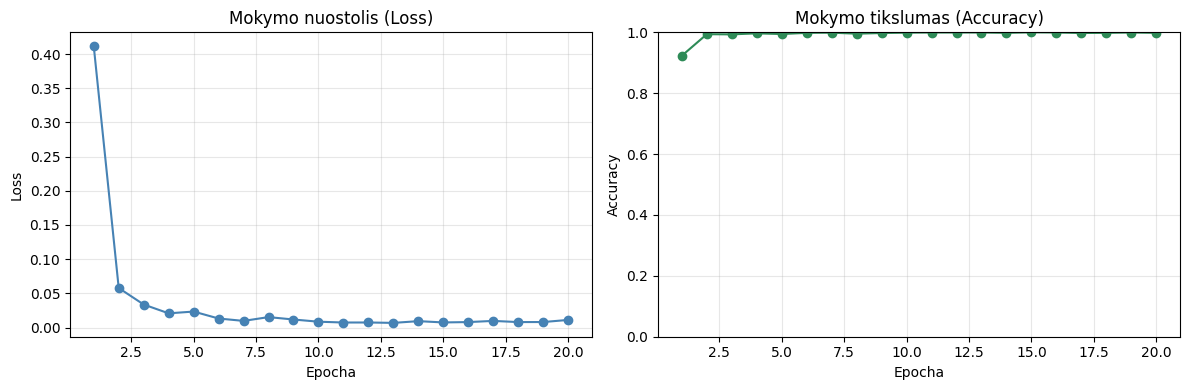

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, num_epochs+1), train_losses, marker='o', color='steelblue')
axes[0].set_title("Mokymo nuostolis (Loss)")
axes[0].set_xlabel("Epocha")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, num_epochs+1), train_accs, marker='o', color='seagreen')
axes[1].set_title("Mokymo tikslumas (Accuracy)")
axes[1].set_xlabel("Epocha")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#lol

## Testavimas ir metrikos

Testavimo aibėje skaičiuojame:
- **Klasifikavimo matrica** (confusion matrix)
- **Tikslumas** (accuracy)
- **Precizija** (precision)
- **Atkūrimas** (recall)
- **F1** (F1-score)

Visos metrikos skaičiuojamos tiek kiekvienai klasei atskirai, tiek makro vidurkiu.

In [12]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Metrikos ---
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

print(f"{'Klase':<10} {'Precizija':>10} {'Atkurimas':>10} {'F1':>8}")
print("-" * 42)
for i, cls in enumerate(classes):
    print(f"{cls:<10} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>8.4f}")

print("-" * 42)
print(f"{'Makro':<10} {precision.mean():>10.4f} {recall.mean():>10.4f} {f1.mean():>8.4f}")
print(f"\nBendras tikslumas: {accuracy:.4f}")

print("\nISAMUS PRANESIMAS:")
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

Klase       Precizija  Atkurimas       F1
------------------------------------------
Train          1.0000     1.0000   1.0000
Bee            1.0000     1.0000   1.0000
Castle         1.0000     1.0000   1.0000
------------------------------------------
Makro          1.0000     1.0000   1.0000

Bendras tikslumas: 1.0000

ISAMUS PRANESIMAS:
              precision    recall  f1-score   support

       Train       1.00      1.00      1.00       201
         Bee       1.00      1.00      1.00       195
      Castle       1.00      1.00      1.00        53

    accuracy                           1.00       449
   macro avg       1.00      1.00      1.00       449
weighted avg       1.00      1.00      1.00       449



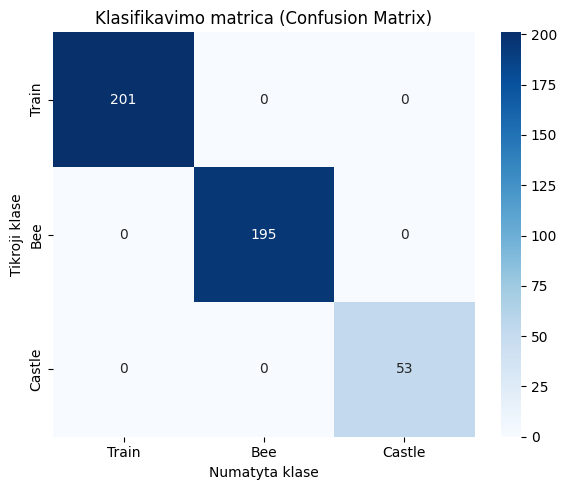

In [13]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
)
ax.set_xlabel("Numatyta klase")
ax.set_ylabel("Tikroji klase")
ax.set_title("Klasifikavimo matrica (Confusion Matrix)")
plt.tight_layout()
plt.show()

In [14]:
save_dir = 'models'
save_path = os.path.join(save_dir, 'efficientnet_b0_finetuned.pth')
safe_path = os.path.join(save_dir, 'efficientnet_b0_finetuned.safetensors')
os.makedirs(save_dir, exist_ok=True)

# DirectML aplinkoje torch.save gali mesti ModuleNotFoundError del torch/torchvision nesuderinamumo.
state_dict_cpu = {k: v.detach().cpu().contiguous() for k, v in model.state_dict().items()}

try:
    torch.save(state_dict_cpu, save_path)
    print(f"Modelis issaugotas: {save_path}")
except ModuleNotFoundError as e:
    if "torch.utils.serialization" in str(e):
        from safetensors.torch import save_file
        save_file(state_dict_cpu, safe_path)
        print("[WARN] torch.save nepavyko del torch.utils.serialization klaidos.")
        print(f"Modelis issaugotas alternatyviu formatu: {safe_path}")
    else:
        raise

Modelis issaugotas: models\efficientnet_b0_finetuned.pth
